![Machine Learning Lab](banner.jpg)


# Laboratorio 4 Actividad


## Instrucciones generales


1. Esta actividad debe ser entregada por BN y es de carácter individual. No se permite entregar el laboratorio después de la fecha establecida.
2. Al responder las preguntas de las actividades por favor marcar las respuestas con la sección a la que corresponden, por ejemplo: `## Exploración de datos 2.1`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor nombrar el archivo de acuerdo al siguiente formato `{email}_lab4.ipynb`.
4. Si tienen alguna duda pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams

Para este laboratorio deben usar el siguiente dataset de Telco Customer Churn: `https://www.kaggle.com/datasets/mosapabdelghany/telcom-customer-churn-dataset`

* * *

Instrucciones
-------------

### 0\. Descarga del Dataset

Utiliza el siguiente enlace para descargar el dataset de Telco Customer Churn desde Kaggle:

[Descargar Dataset](https://www.kaggle.com/datasets/mosapabdelghany/telcom-customer-churn-dataset)

El dataset contiene información de clientes de una empresa de telecomunicaciones y su comportamiento de abandono (churn). En este laboratorio nuestra variable objetivo será la columna `Churn`.

### 1\. Exploración de datos (5%)

1. Carga el dataset en un DataFrame de pandas.
2. Analiza la distribución de la variable objetivo `Churn` y crea una visualización con un gráfico de barras.

### 2\. Preprocesamiento de Datos (15%)

1. **Limpieza de datos**: Convierte la columna `TotalCharges` a numérico y maneja los valores nulos reemplazándolos por `MonthlyCharges * tenure`.
2. **Eliminar columna irrelevante**: Remueve la columna `customerID`.
3. **Separación de variables**: Separa las características (X) de la variable objetivo (y = `Churn`).
4. **División train/test**: Divide los datos en conjuntos de entrenamiento y prueba usando `train_test_split` con `test_size=0.2`, `random_state=42` y `stratify=y`.
5. **Pipeline de preprocesamiento**: Crea pipelines separados para variables numéricas (con `SimpleImputer` y `StandardScaler`) y categóricas (con `SimpleImputer` y `OneHotEncoder`), luego combínalos con `ColumnTransformer`.

### 3\. Entrenamiento de modelo (60%)

Para cada uno de los siguientes modelos `DecisionTreeClassifier, RandomForestClassifier, AdaBoostClassifier, XGBClassifier` realizar los siguientes pasos:

1. **Entrenar el modelo**: Ajusta cada modelo usando los datos de entrenamiento preprocesados. Usa `LabelEncoder` para convertir las etiquetas categóricas a numérica.
2. **Matriz de confusión**: Grafica la matriz de confusión del modelo.
3. **Reporte de clasificación**: Genera y muestra el reporte de clasificación.
4. **Análisis SHAP**: Grafica los valores SHAP para interpretar la importancia de las variables (Excluyendo AdaBoostClassifier).
5. **Árbol de decisión**: Para `DecisionTreeClassifier`, grafica los primeros 3 niveles del árbol.
6. **Importancia de variables**: ¿Cuales son las dos variables más importantes para esta tarea de clasificación según los resultados obtenidos? Justifique su respuesta.


### 4\. Gráfica de frontera de decisiones (20%)

1. **Visualización de fronteras**: Usa la función `plot_class_boundaries` presentada abajo para graficar las fronteras de decisión de un `DecisionTreeClassifier` y un `RandomForestClassifier`. Utiliza las dos variables numéricas más importantes identificadas en el punto anterior con valores de `max_depth` de `3, 10, 100`.

¿Qué diferencias observa entre usar `max_depth=3`, `max_depth=10` y `max_depth=100`? ¿Cómo cree que esto afecte el overfitting? Analice las fronteras de decisión y la estructura del árbol.


In [1]:
from sklearn.tree import plot_tree, DecisionTreeClassifier
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import matplotlib.cm as cm

def generate_palette(n, cmap_name='viridis'):
    cmap = cm.get_cmap(cmap_name, n)
    return [mcolors.to_hex(cmap(i)) for i in range(n)]


def plot_class_boundaries(X_train_processed, y_train, column_1, column_2, model_class, **model_kwargs):
    """
    Grafica las fronteras de decisión de un modelo de clasificación basado en dos características
    seleccionadas de los datos de entrenamiento. Esta función ajusta el modelo dado en las
    columnas de características proporcionadas y visualiza las regiones de decisión, fronteras
    de clase y puntos de entrenamiento en un gráfico 2D.

    :param X_train_processed: DataFrame que contiene los datos de entrenamiento procesados.
    :param y_train: Las etiquetas objetivo correspondientes a los datos de entrenamiento.
    :param column_1: El nombre de la primera columna de características para graficar fronteras.
    :param column_2: El nombre de la segunda columna de características para graficar fronteras.
    :param model_class: La clase de clasificador a instanciar para ajuste y visualización.
    :param model_kwargs: Argumentos adicionales para inicializar la instancia del clasificador.
    :return: None
    """
    # Extraer solo las dos columnas especificadas
    X_train_selected = X_train_processed[[column_1, column_2]].values

    # Codificar y_train a binario para la visualización
    y_train_binary = (y_train == 'Yes').astype(int)

    # Entrenar el modelo
    model = model_class(**model_kwargs)
    model.fit(X_train_selected, y_train_binary)

    # Generar una malla de puntos
    x_min, x_max = X_train_selected[:, 0].min() - 1, X_train_selected[:, 0].max() + 1
    y_min, y_max = X_train_selected[:, 1].min() - 1, X_train_selected[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Predecir en la malla
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Generar paleta de colores
    # Configurar colores
    colors = ['lightblue', 'lightcoral']
    cmap = ListedColormap(colors)

    # Graficar fronteras de decisión
    plt.figure(figsize=(12, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)

    # Graficar puntos de entrenamiento
    scatter = plt.scatter(X_train_selected[:, 0], X_train_selected[:, 1], c=y_train_binary, cmap=cmap, edgecolor='k')

    # Etiquetas y título
    plt.xlabel(column_1)
    plt.ylabel(column_2)
    plt.title(f'Fronteras de Decisión usando {model_class.__name__}')

    # Agregar leyenda
    handles, labels = scatter.legend_elements()
    plt.legend(handles, labels, title="Clases")
    plt.show()

    if model_class == DecisionTreeClassifier:
        # graficar la estructura del árbol
        plt.figure(figsize=(15, 10))
        plot_tree(model, filled=True, feature_names=[column_1, column_2], 
                 class_names=['No Churn', 'Churn'], fontsize=10)
        plt.title(f'Estructura del Árbol - {model_kwargs}', fontsize=14)
        plt.tight_layout()
        plt.show()

## 0. Descarga del Dataset

In [2]:
!mkdir datasets/
!curl -L -o datasets/telcom-customer-churn-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/mosapabdelghany/telcom-customer-churn-dataset
!unzip datasets/telcom-customer-churn-dataset.zip -d datasets/telcom-customer-churn-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  171k  100  171k    0     0   167k      0  0:00:01  0:00:01 --:--:--  167k
Archive:  datasets/telcom-customer-churn-dataset.zip
  inflating: datasets/telcom-customer-churn-dataset/Telco_Cusomer_Churn.csv  


## 1. Exploración de datos

### 1.1 Carga del dataset en un DataFrame de pandas

In [2]:
import pandas as pd
import seaborn as sns
import os

dataset_path = os.path.expanduser('datasets/telcom-customer-churn-dataset/Telco_Cusomer_Churn.csv')
df = pd.read_csv(dataset_path)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.2 Análisis de la distribución de la variable objetivo `Churn` y visualización


Churn
No     5174
Yes    1869
Name: count, dtype: int64


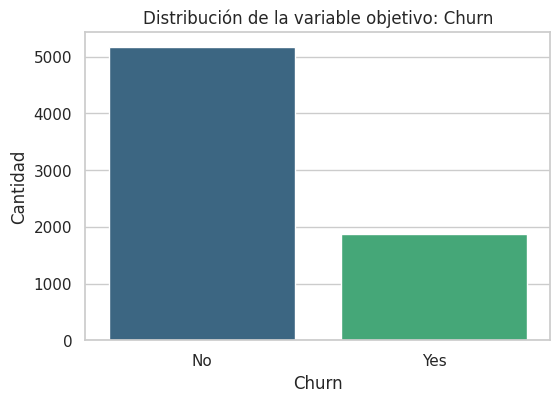

In [3]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6,4))
sns.barplot(x=churn_counts.index, y=churn_counts.values, hue=churn_counts.index, palette="viridis")
plt.title('Distribución de la variable objetivo: Churn')
plt.xlabel('Churn')
plt.ylabel('Cantidad')
plt.show()

## 2. Preprocesamiento de Datos

### 2.1 Limpieza de datos: convertir `TotalCharges` a numérico y manejar nulos

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
nulos = df['TotalCharges'].isnull().sum()
print(f'Valores nulos en TotalCharges: {nulos}')

df.loc[df['TotalCharges'].isnull(), 'TotalCharges'] = df['MonthlyCharges'] * df['tenure']
df['TotalCharges'] = df['TotalCharges'].astype(float)

print(f'Valores nulos en TotalCharges después de la imputación: {df["TotalCharges"].isnull().sum()}')

Valores nulos en TotalCharges: 11
Valores nulos en TotalCharges después de la imputación: 0


### 2.2 Eliminar columna irrelevante: `customerID`


In [5]:
df = df.drop('customerID', axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.3 Separación de variables: características (X) y variable objetivo (y)


In [6]:
X = df.drop('Churn', axis=1)
y = df['Churn']

### 2.4 División train/test


In [7]:
# 2.4 División train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 2.5 Pipeline de preprocesamiento


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

## 3. Entrenamiento de modelo
### 3.1 Entrenar modelos y convertir etiquetas


In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

models = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'XGB': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

model_results = {}
for name, model in models.items():
    model.fit(X_train_processed, y_train_enc)
    y_pred = model.predict(X_test_processed)
    model_results[name] = {'model': model, 'y_pred': y_pred}
    
print('Modelos entrenados:', list(models.keys()))

Modelos entrenados: ['DecisionTree', 'RandomForest', 'AdaBoost', 'XGB']


/home/jabu/codes/college/MLT/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:55:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### 3.2 Matriz de confusión


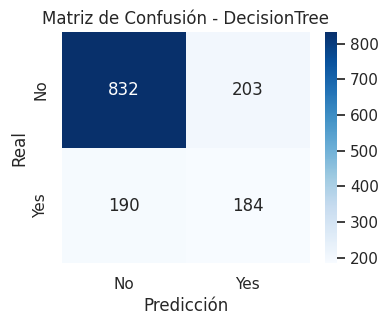

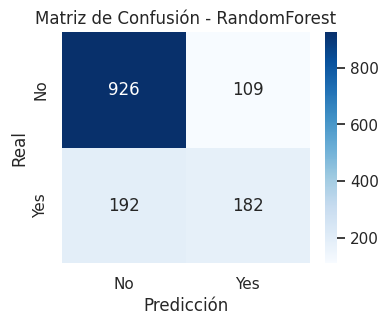

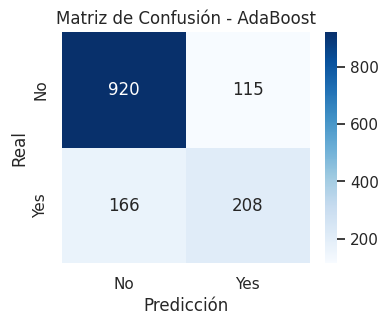

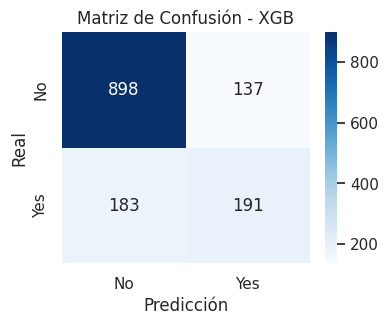

In [10]:
for name, result in model_results.items():
    cm = confusion_matrix(y_test_enc, result['y_pred'])
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Matriz de Confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

### 3.3 Reporte de clasificación


In [11]:
# 3.3 Reporte de clasificación
for name, result in model_results.items():
    print(f'\nReporte de clasificación para {name}:')
    print(classification_report(y_test_enc, result['y_pred'], target_names=le.classes_))


Reporte de clasificación para DecisionTree:
              precision    recall  f1-score   support

          No       0.81      0.80      0.81      1035
         Yes       0.48      0.49      0.48       374

    accuracy                           0.72      1409
   macro avg       0.64      0.65      0.65      1409
weighted avg       0.72      0.72      0.72      1409


Reporte de clasificación para RandomForest:
              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1035
         Yes       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409


Reporte de clasificación para AdaBoost:
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.64      0.56      0.60       374

    accuracy                           0.80      14

### 3.4 Análisis SHAP (excepto AdaBoost)


In [ ]:
import shap
%matplotlib inline

feature_names = num_features + list(preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_features))

shap_models = ['DecisionTree', 'RandomForest', 'XGB']
for name in shap_models:
    model = model_results[name]['model']
    explainer = shap.Explainer(model, X_train_processed, feature_names=feature_names)
    shap_values = explainer(X_test_processed, check_additivity=False)
    print(f'Valores SHAP para {name}:')
    shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names, show=True)

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

### 3.5 Árbol de decisión: graficar los primeros 3 niveles


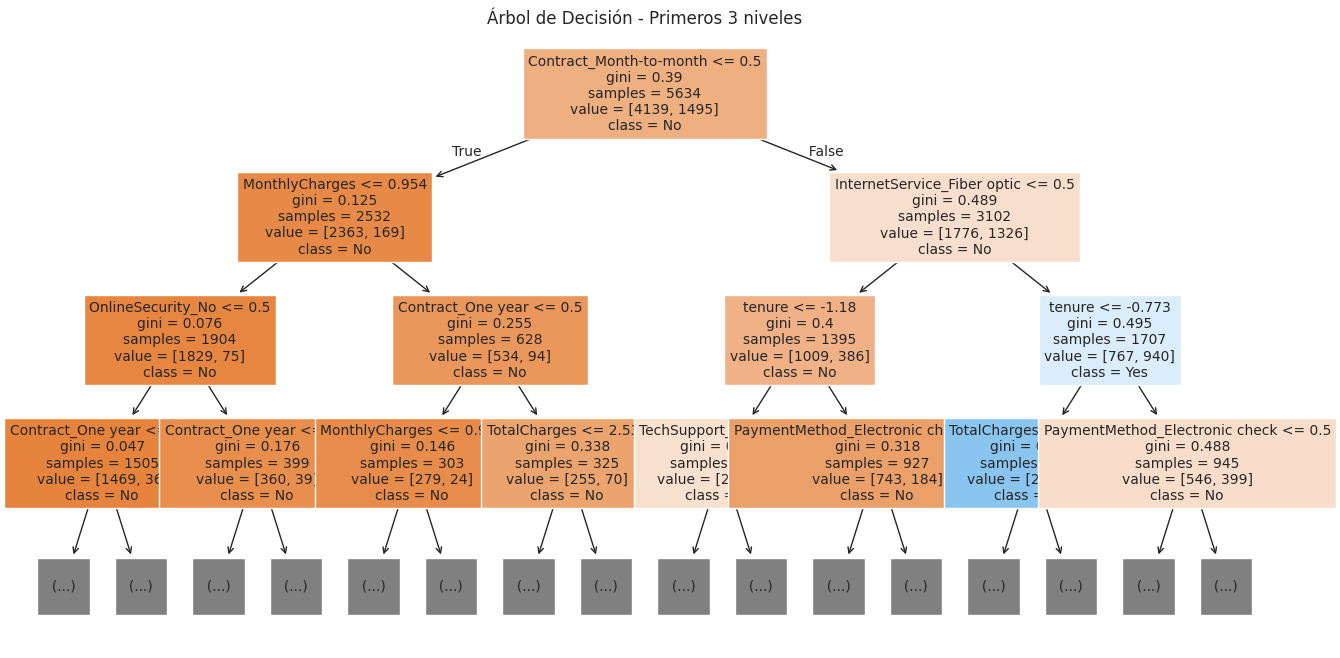

In [ ]:
plt.figure(figsize=(16, 8))
plot_tree(model_results['DecisionTree']['model'], max_depth=3, filled=True, feature_names=feature_names, class_names=le.classes_, fontsize=10)
plt.title('Árbol de Decisión - Primeros 3 niveles')
plt.show()

### 3.6 Importancia de variables: ¿Cuáles son las dos variables más importantes?


In [13]:
# 3.6 Importancia de variables: ¿Cuáles son las dos variables más importantes?
importances = model_results['RandomForest']['model'].feature_importances_
indices = np.argsort(importances)[::-1]
top_vars = [feature_names[i] for i in indices[:2]]
print('Las dos variables más importantes según RandomForest son:', top_vars)

Las dos variables más importantes según RandomForest son: ['TotalCharges', 'tenure']


> Justificación: Estas variables tienen mayor peso en la predicción del modelo, lo que indica que su variación influye significativamente en la decisión de churn. Esto se observa tanto en la importancia del modelo como en los valores SHAP.

## 4. Gráfica de frontera de decisiones
### 4.1 Visualización de fronteras de decisión



Frontera DecisionTreeClassifier con max_depth=3


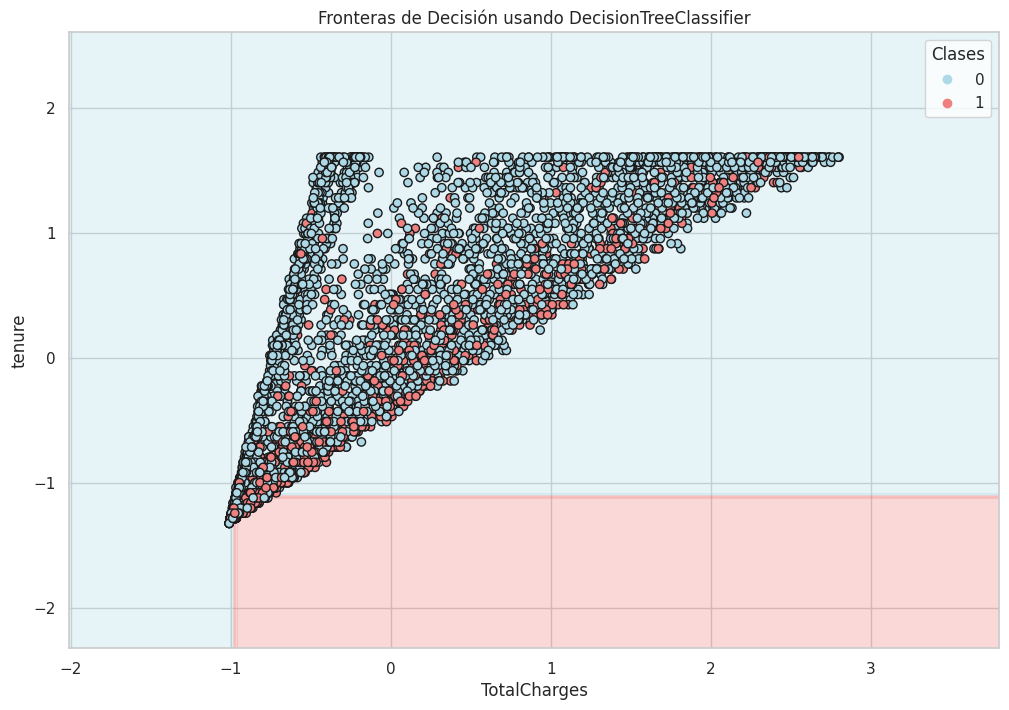

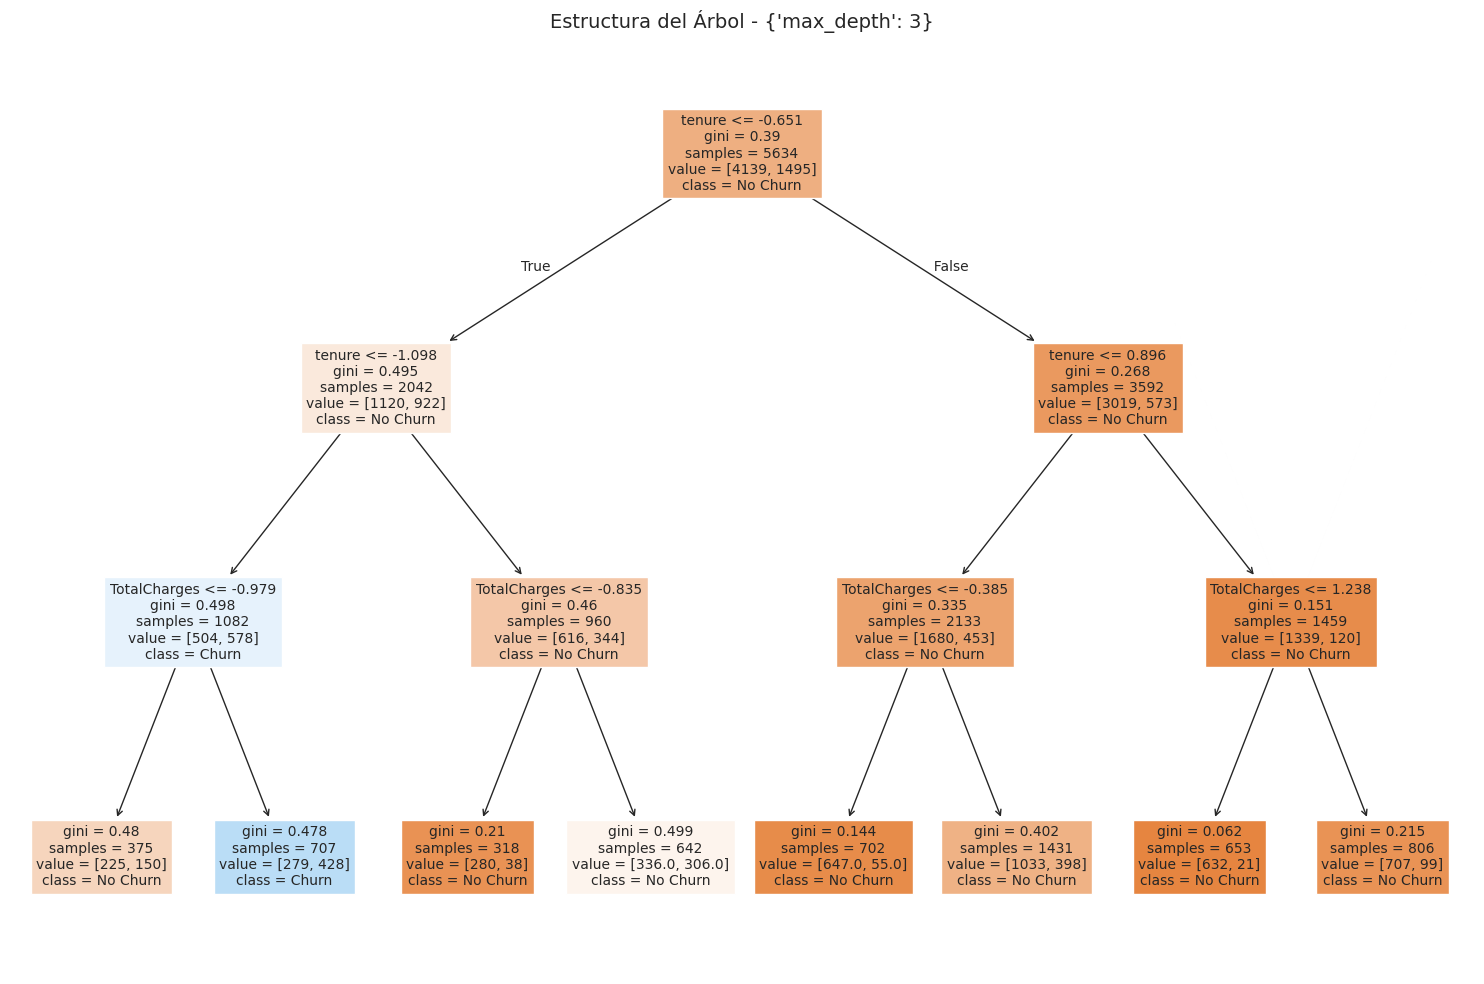


Frontera DecisionTreeClassifier con max_depth=10


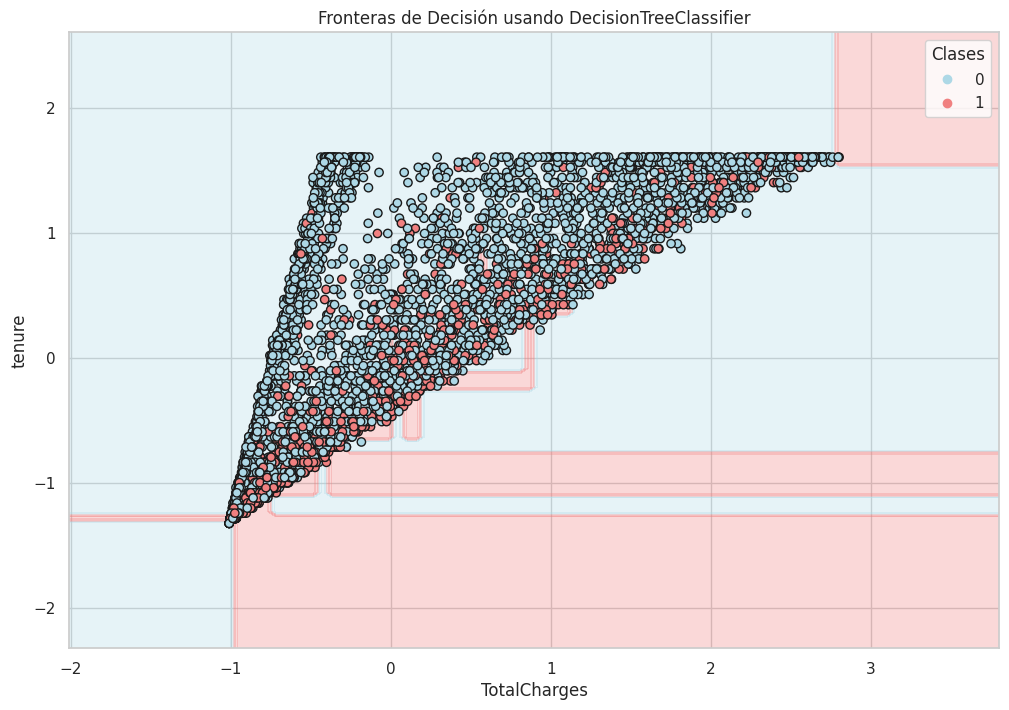

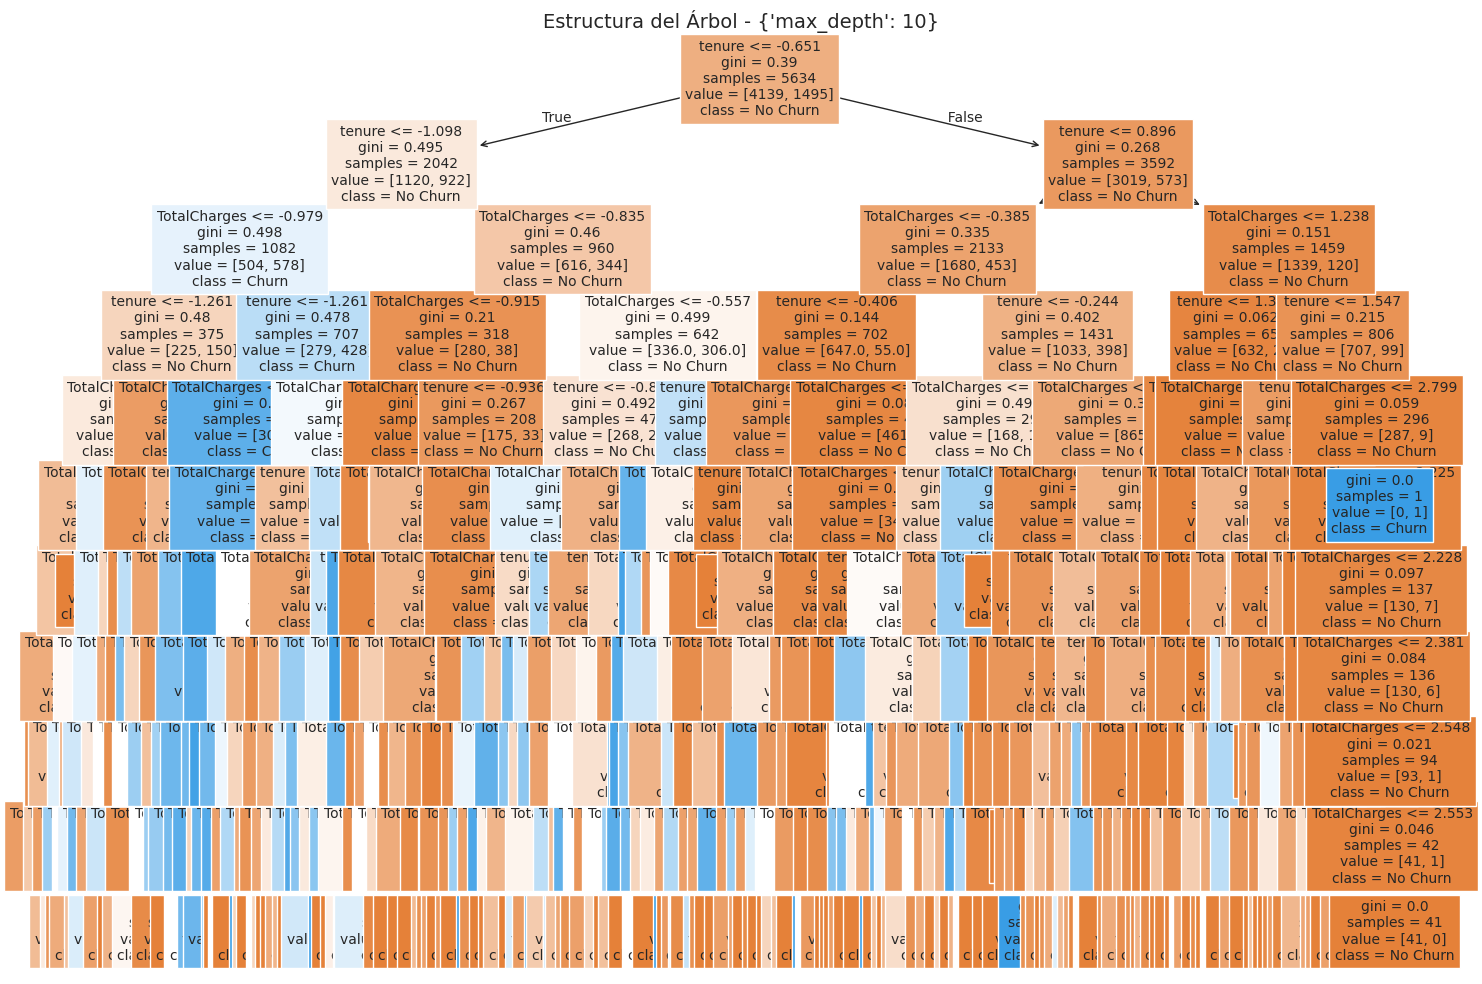


Frontera DecisionTreeClassifier con max_depth=100


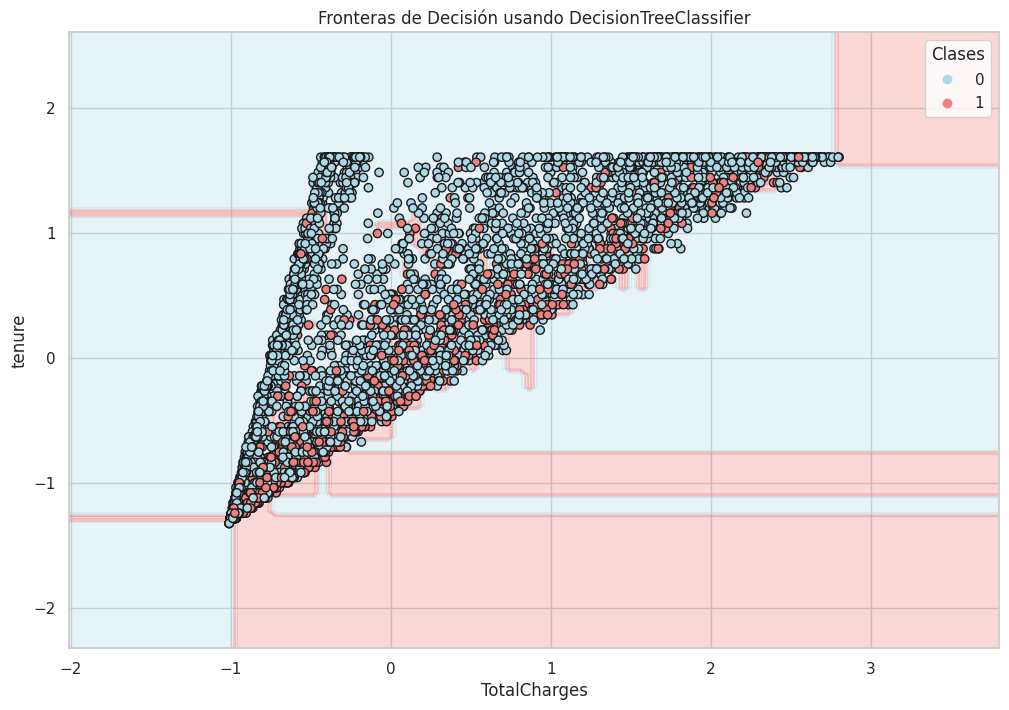

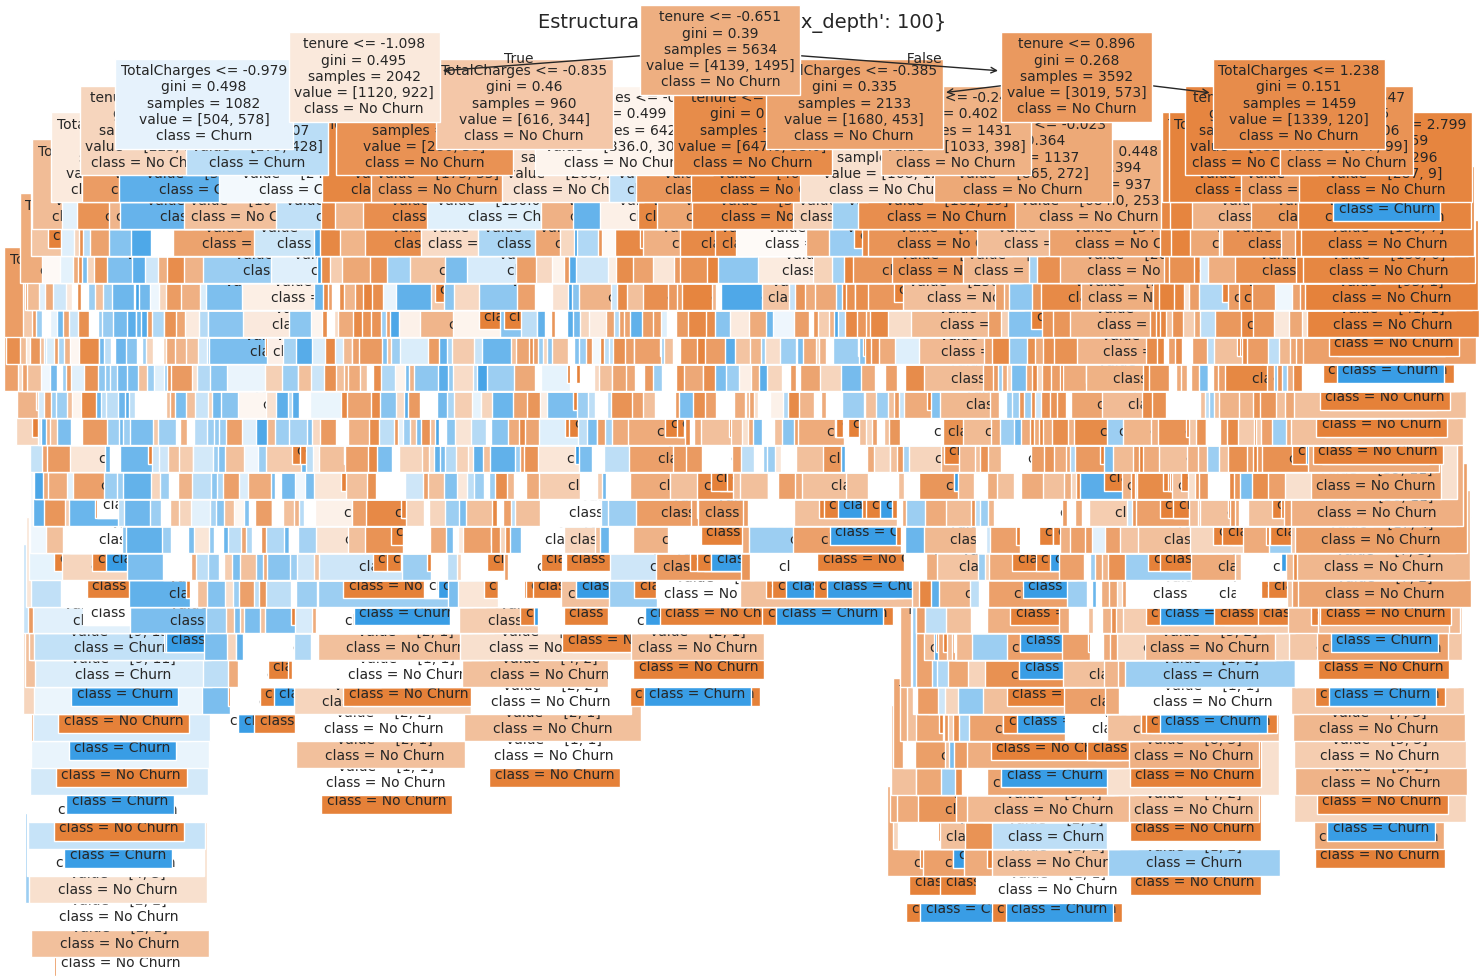


Frontera RandomForestClassifier con max_depth=3


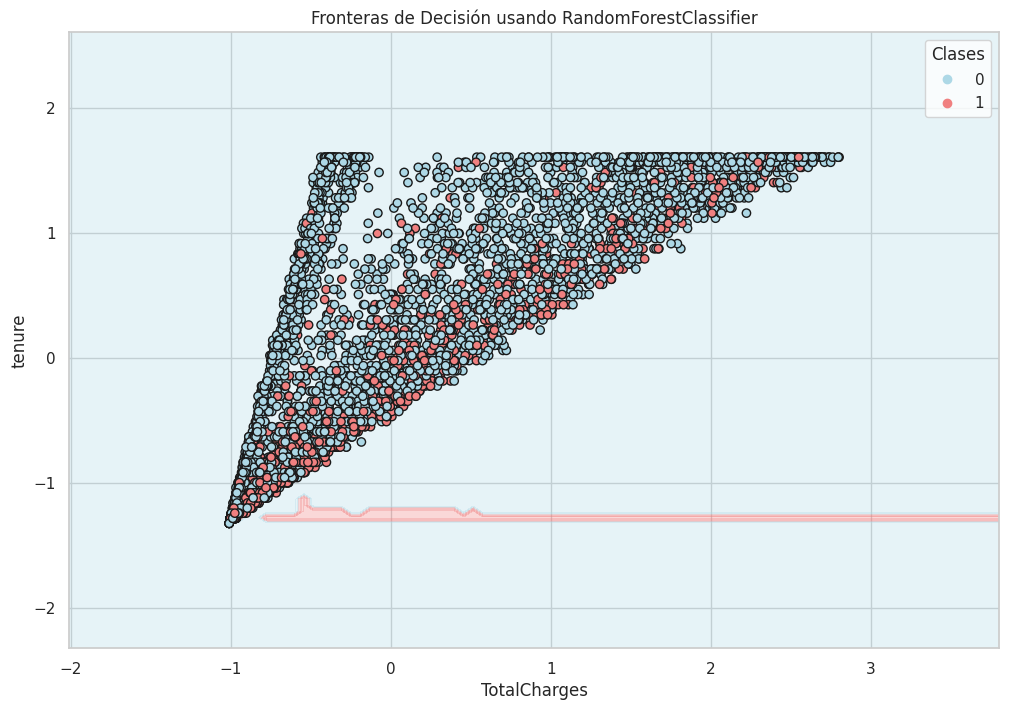


Frontera RandomForestClassifier con max_depth=10


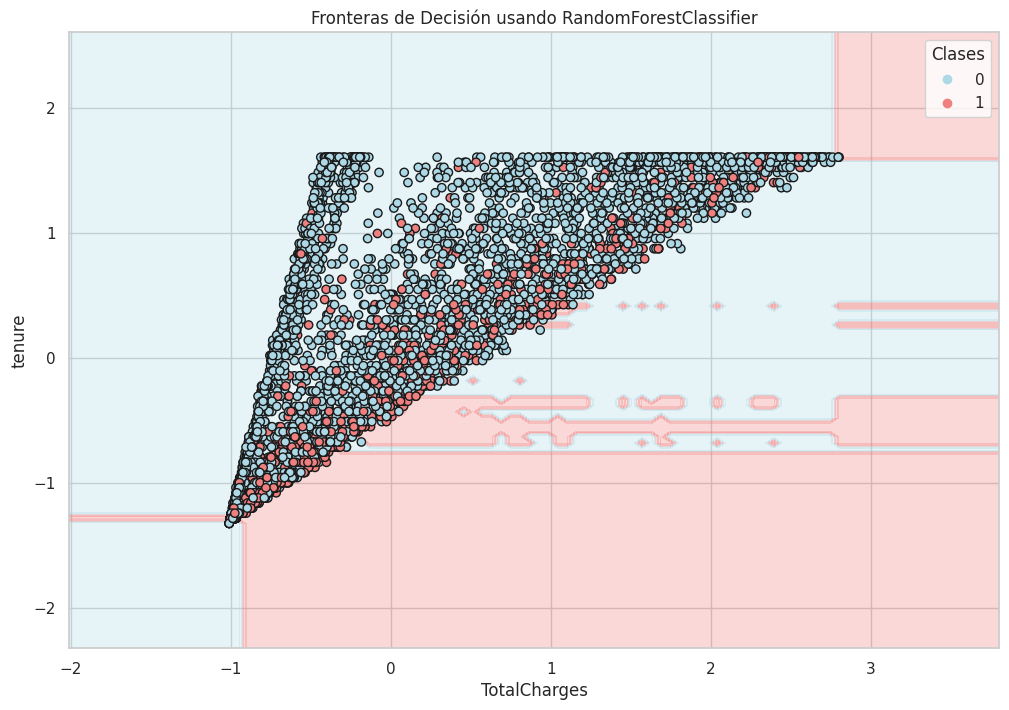


Frontera RandomForestClassifier con max_depth=100


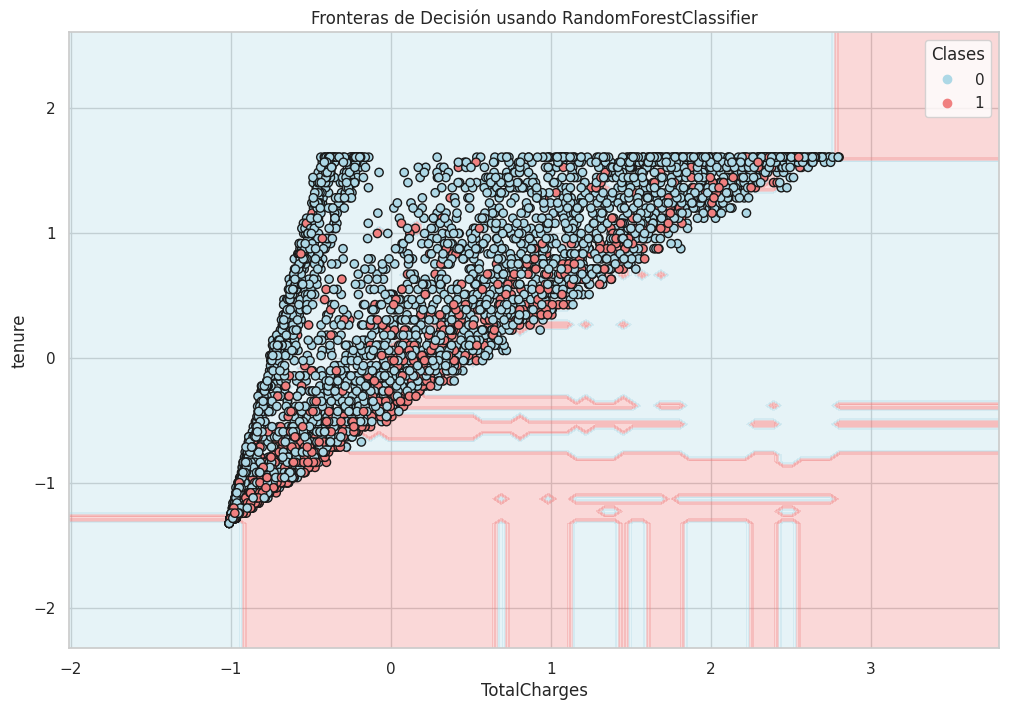

In [ ]:
for max_depth in [3, 10, 100]:
    print(f'\nFrontera DecisionTreeClassifier con max_depth={max_depth}')
    plot_class_boundaries(pd.DataFrame(X_train_processed, columns=feature_names), y_train, top_vars[0], top_vars[1], DecisionTreeClassifier, max_depth=max_depth)

for max_depth in [3, 10, 100]:
    print(f'\nFrontera RandomForestClassifier con max_depth={max_depth}')
    plot_class_boundaries(pd.DataFrame(X_train_processed, columns=feature_names), y_train, top_vars[0], top_vars[1], RandomForestClassifier, max_depth=max_depth)

### 4.2 Análisis de diferencias entre max_depth y overfitting

- Al aumentar el parámetro `max_depth`, las fronteras de decisión se vuelven más complejas y ajustadas a los datos de entrenamiento.
- Con `max_depth=3`, el modelo es más simple y generaliza mejor, pero puede perder detalles importantes.
- Con `max_depth=10`, el modelo captura más patrones, pero puede empezar a sobreajustar.
- Con `max_depth=100`, el modelo probablemente sobreajusta, creando fronteras muy irregulares que no generalizan bien.
- El overfitting ocurre cuando el modelo aprende demasiado los datos de entrenamiento y pierde capacidad de generalización.
- En la estructura del árbol, se observa que a mayor profundidad, el árbol tiene más nodos y ramas, lo que puede llevar a decisiones basadas en ruido.
